In [20]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from cuml.manifold import TSNE, UMAP
from cuml import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
SSR_synth_lst = []

for _ in range(7):
    SSR_synth_ds = DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/synth"),
        extensions = (".mat"),
        transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.8, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
        loader = mat_file_loader
    )

    SSR_synth_ds_14_15_16 = filter_by_elev(SSR_synth_ds, {14, 15, 16})
    s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(SSR_synth_ds_14_15_16, bin_width=10)
    print_bin_summary(b, SSR_synth_ds_14_15_16)
    new_SSR_synth_ds_14_15_16 = AzimuthBinnedDataset(SSR_synth_ds_14_15_16, s, new_classes)

    SSR_synth_lst.append(new_SSR_synth_ds_14_15_16)

new_SSR_synth_ds_big_14_15_16 = ConcatDataset(SSR_synth_lst)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)
Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35      

In [7]:
meas_ds_14_15_16 = filter_by_elev(meas_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_14_15_16, bin_width=10)
print_bin_summary(b, meas_ds_14_15_16)

new_meas_ds_14_15_16 = AzimuthBinnedDataset(meas_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [8]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [9]:
train_ds = new_SSR_synth_ds_big_14_15_16
valid_ds = new_meas_ds_14_15_16
test_ds  = new_meas_ds_17

In [10]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [100, 200, 400, 500, 750, 1000]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor  = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor   = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in test_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        correct = torch.sum(preds_tensor == labels_tensor).item()
        total = n_test

        test_acc = correct / total
        print(f"Test Accuracy: {test_acc*100:.4f}")
        test_acc_lst.append(test_acc)

    test_acc_arr = np.array(test_acc_lst)
    print(f"Min: {test_acc_arr.min() * 100:.4f}")
    print(f"Max: {test_acc_arr.max() * 100:.4f}")
    print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")


Evaluating with k=100 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 68.0891
Evaluating Run 1: seed 42
Test Accuracy: 70.3154
Evaluating Run 2: seed 100
Test Accuracy: 68.4601
Evaluating Run 3: seed 123
Test Accuracy: 72.5417
Evaluating Run 4: seed 666
Test Accuracy: 68.6456
Evaluating Run 5: seed 777
Test Accuracy: 67.1614
Evaluating Run 6: seed 849
Test Accuracy: 67.3469
Evaluating Run 7: seed 1000
Test Accuracy: 69.3878
Evaluating Run 8: seed 1111
Test Accuracy: 65.1206
Evaluating Run 9: seed 1234
Test Accuracy: 70.3154
Min: 65.1206
Max: 72.5417
Avg, Std: 68.7384, 1.9463

Evaluating with k=200 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 67.5325
Evaluating Run 1: seed 42
Test Accuracy: 70.6865
Evaluating Run 2: seed 100
Test Accuracy: 69.0167
Evaluating Run 3: seed 123
Test Accuracy: 72.3562
Evaluating Run 4: seed 666
Test Accuracy: 68.6456
Evaluating Run 5: seed 777
Test Accuracy: 66.4193
Evaluating Run 6: seed 849
Test Accur


Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 666


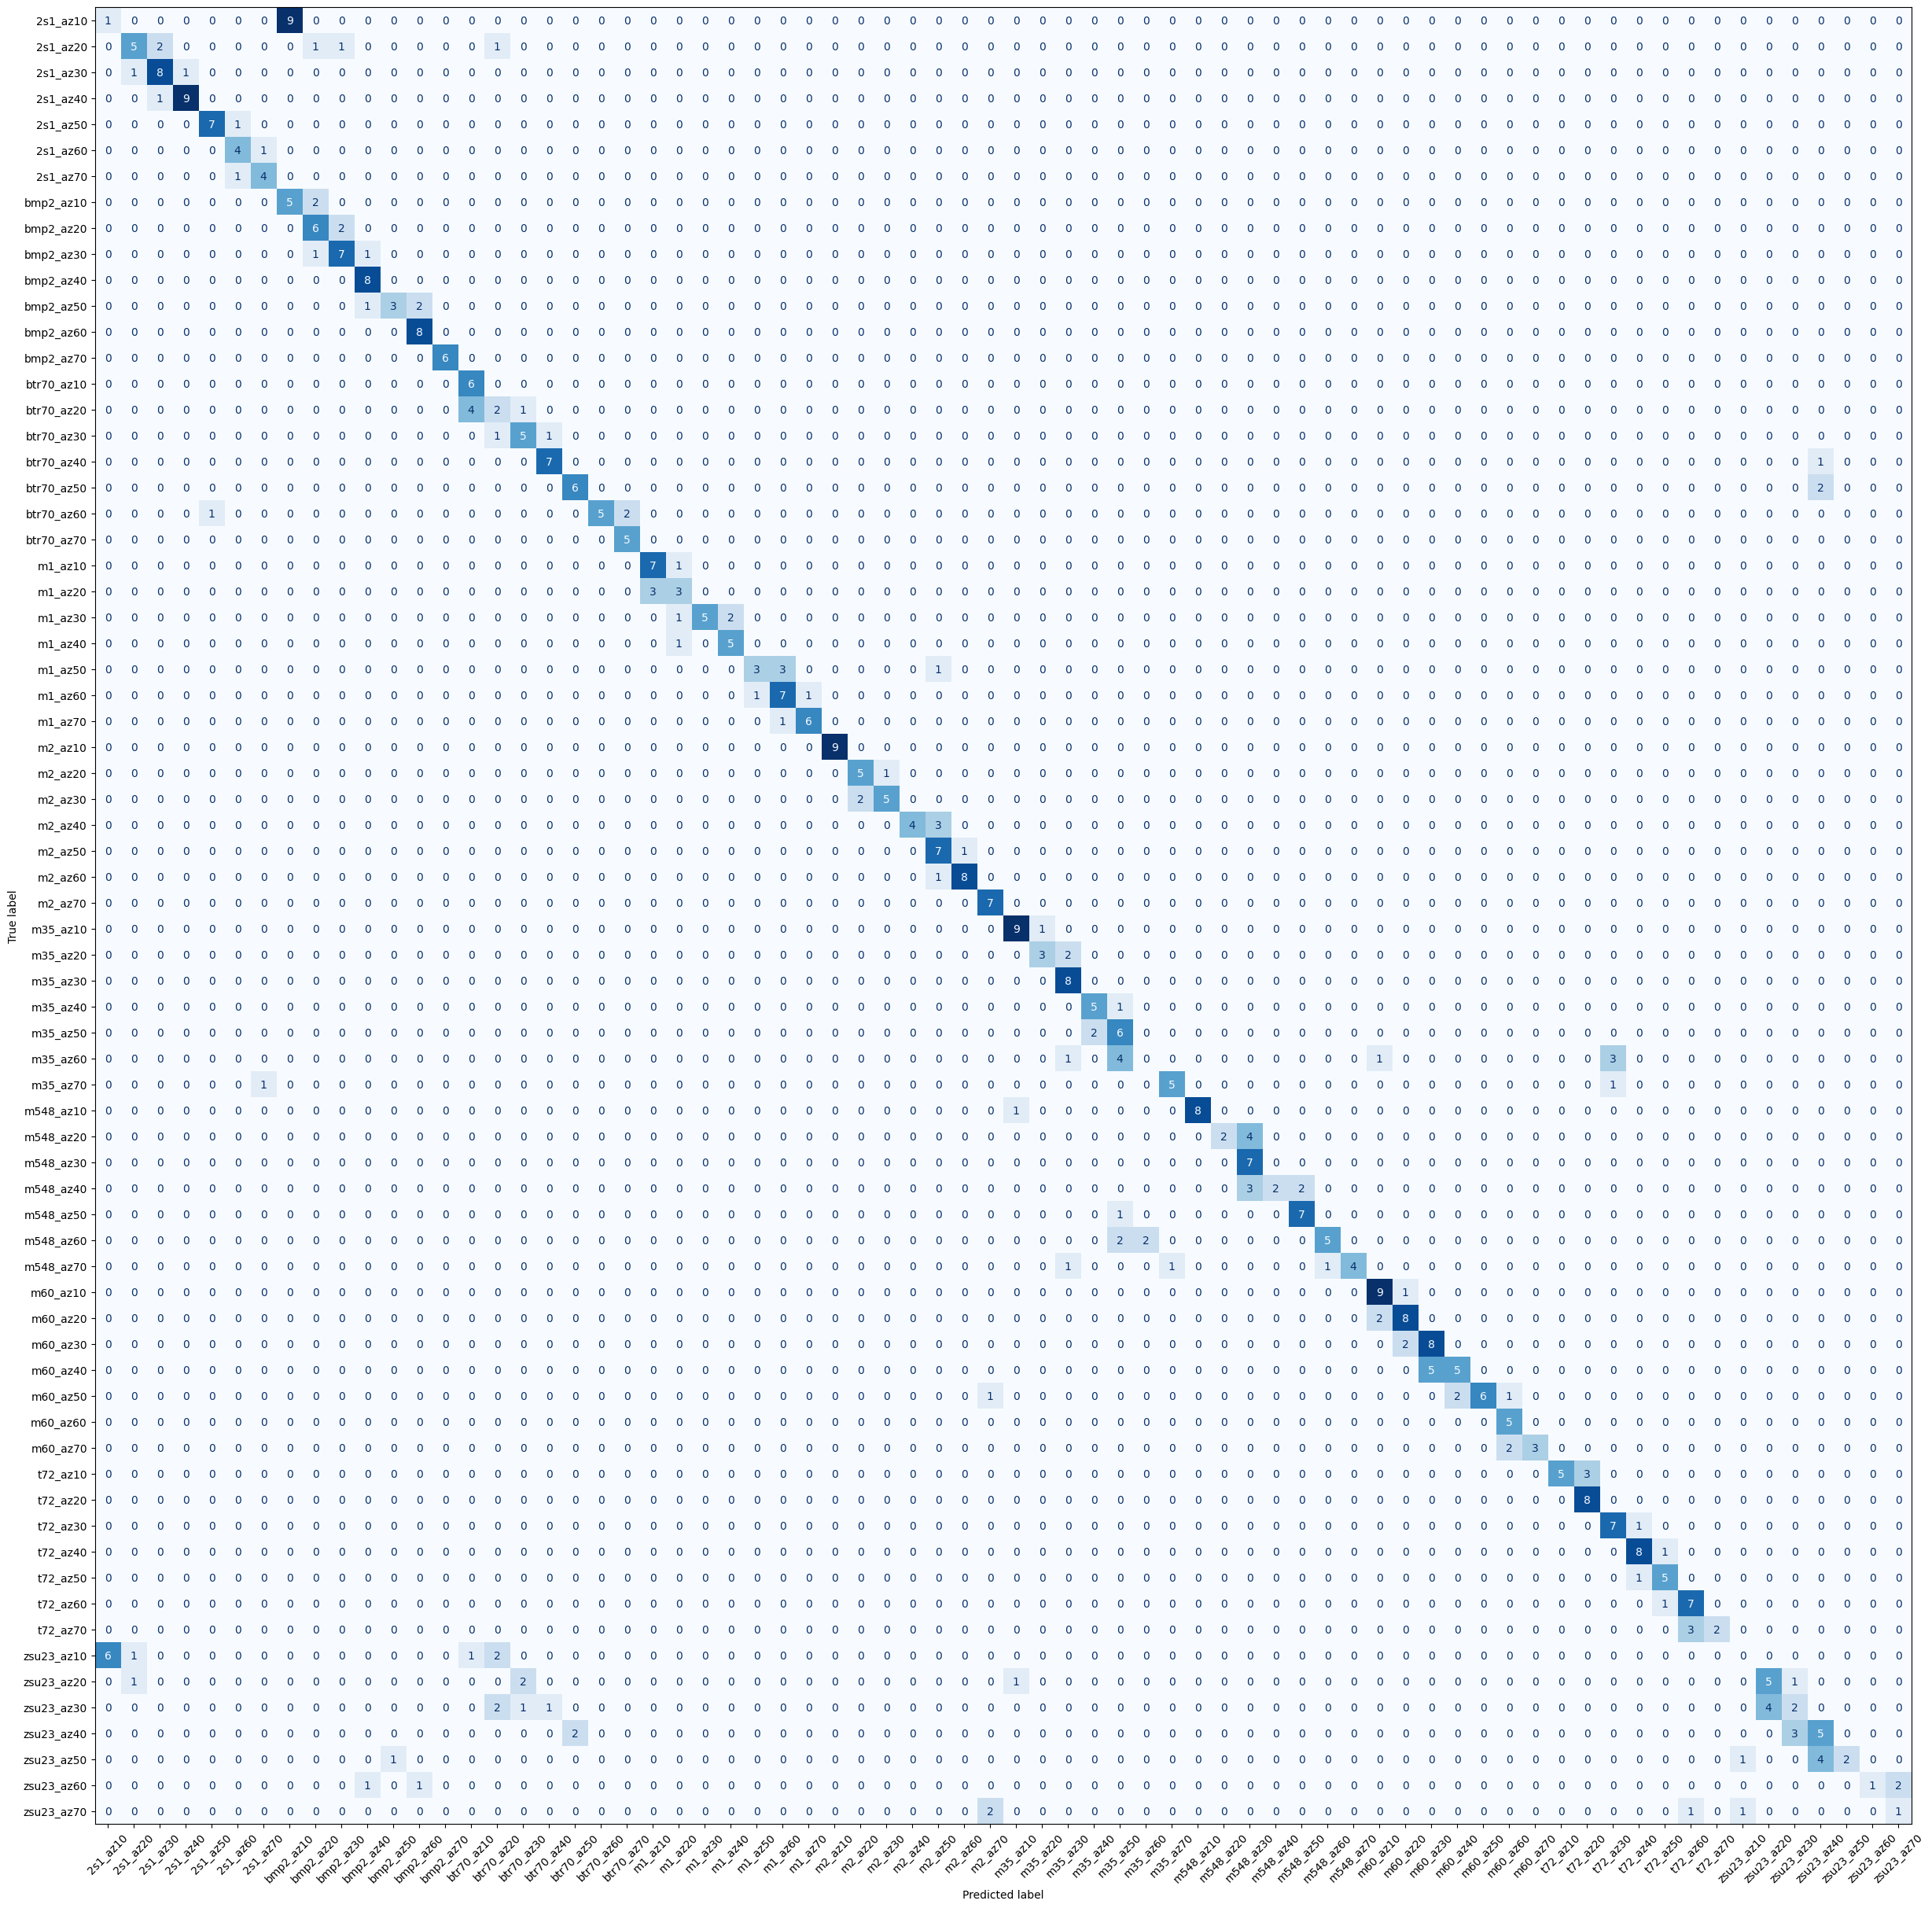

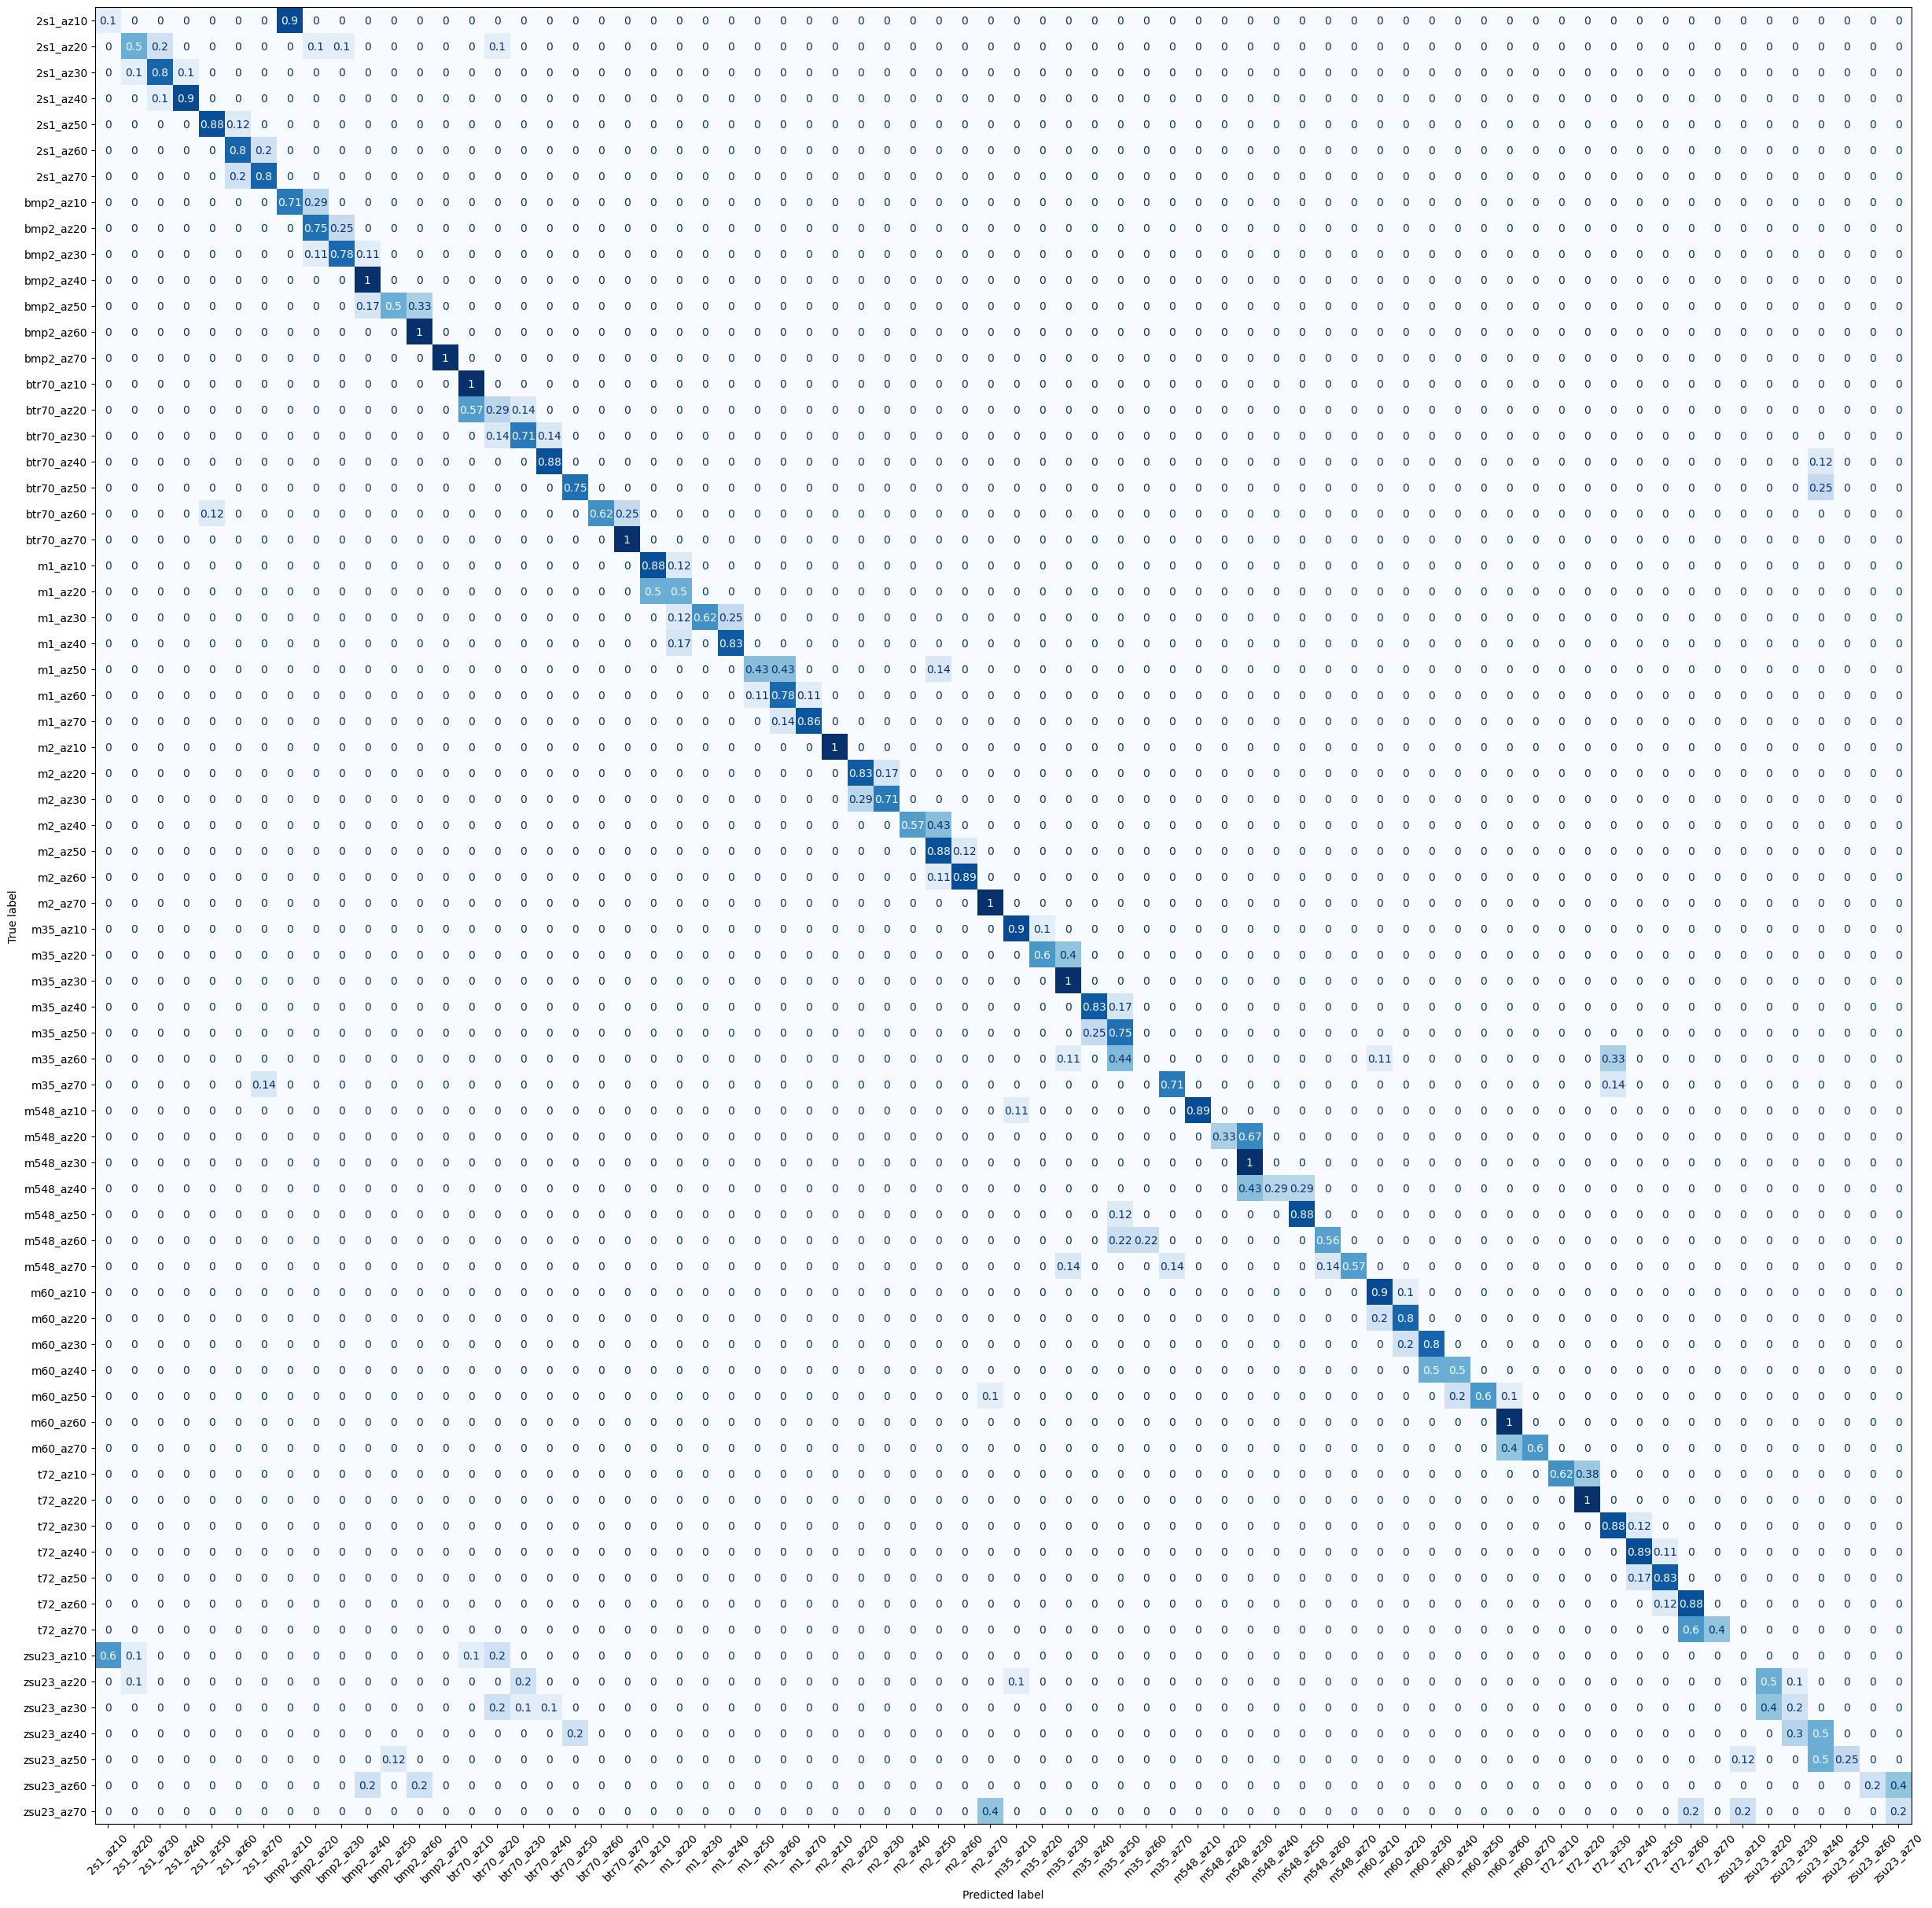

In [11]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [1000]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [666]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_dataloader, desc="Evaluating", leave = False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        _labels_all = labels_tensor.cpu().numpy()
        _preds_all = preds_tensor.cpu().numpy()
    

    # confusion matrix
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu  = cp.asnumpy(cm)

    disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.classes)
    fig, ax = plt.subplots(figsize=(30, 30))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
    cm_norm_cpu  = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.classes)
    fig, ax = plt.subplots(figsize=(30, 30))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

In [12]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [100, 200, 400, 500, 750, 1000]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor  = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor   = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in test_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        _labels_tensor = labels_tensor.cpu().numpy()
        _preds_tensor = preds_tensor.cpu().numpy()
        
        _old_class_labels = np.array([new_to_old_classes[_labels_tensor[i]] for i in range(len(_labels_tensor))])
        _old_class_preds = np.array([new_to_old_classes[_preds_tensor[i]] for i in range(len(_preds_tensor))])
        
        test_acc = (_old_class_labels == _old_class_preds).mean()
        print(f"Test Accuracy: {test_acc*100:.4f}")
        test_acc_lst.append(test_acc)

    test_acc_arr = np.array(test_acc_lst)
    print(f"Min: {test_acc_arr.min() * 100:.4f}")
    print(f"Max: {test_acc_arr.max() * 100:.4f}")
    print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")


Evaluating with k=100 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 92.3933
Evaluating Run 1: seed 42
Test Accuracy: 92.3933
Evaluating Run 2: seed 100
Test Accuracy: 91.2801
Evaluating Run 3: seed 123
Test Accuracy: 92.3933
Evaluating Run 4: seed 666
Test Accuracy: 88.8683
Evaluating Run 5: seed 777
Test Accuracy: 91.0946
Evaluating Run 6: seed 849
Test Accuracy: 90.3525
Evaluating Run 7: seed 1000
Test Accuracy: 91.2801
Evaluating Run 8: seed 1111
Test Accuracy: 89.9814
Evaluating Run 9: seed 1234
Test Accuracy: 90.7236
Min: 88.8683
Max: 92.3933
Avg, Std: 91.0761, 1.0959

Evaluating with k=200 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 92.7644
Evaluating Run 1: seed 42
Test Accuracy: 92.2078
Evaluating Run 2: seed 100
Test Accuracy: 91.4657
Evaluating Run 3: seed 123
Test Accuracy: 92.2078
Evaluating Run 4: seed 666
Test Accuracy: 89.2393
Evaluating Run 5: seed 777
Test Accuracy: 91.0946
Evaluating Run 6: seed 849
Test Accur


Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 666


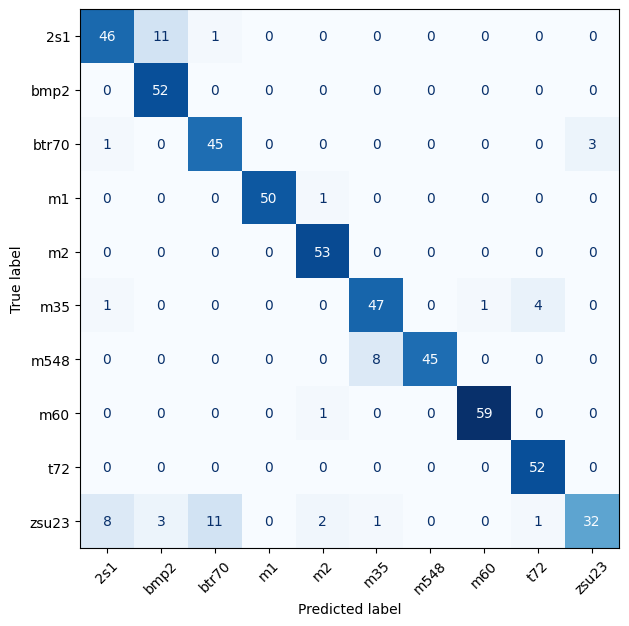

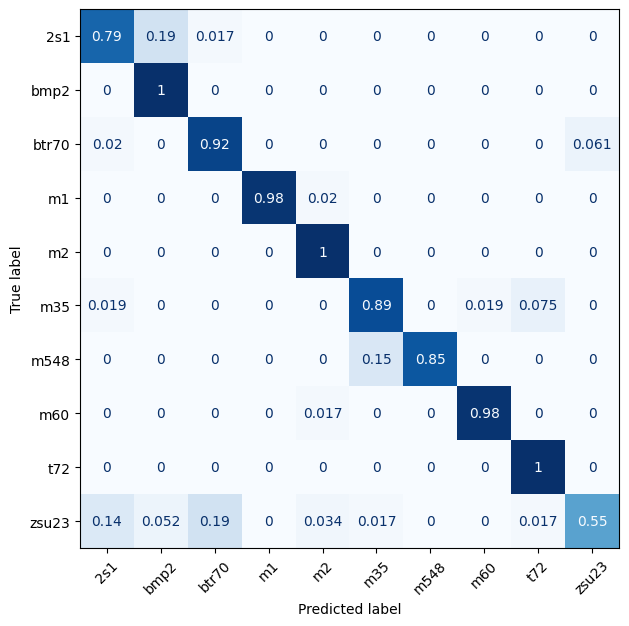

In [13]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [10**3]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [666]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_dataloader, desc="Evaluating", leave = False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        torch.cuda.synchronize()

        _labels_all = labels_tensor.cpu().numpy()
        _preds_all = preds_tensor.cpu().numpy()
    
        _old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
        _old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

    # confusion matrix
    cm = confusion_matrix(_old_class_labels, _old_class_preds)
    cm_cpu  = cp.asnumpy(cm)

    disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.dataset.classes)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

    cm_norm = confusion_matrix(_old_class_labels, _old_class_preds, normalize = "true")
    cm_norm_cpu  = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.dataset.classes)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

In [14]:
def make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle, start_lightness=0.3):
    """
    For each vehicle, interpolate from a light tint to the tab10 base colour.
    Returns a flat list of (R,G,B) colours indexed by new_label (bin index).
    """
    tab10 = plt.colormaps["tab10"]
    bin_colors = []
    
    for v in range(n_vehicles):
        base = np.array(tab10(v)[:3])  # RGB of tab10 colour for vehicle v
        white = np.ones(3)
        # linspace from near-white to full colour, n_bins steps
        # start at start_lightness (not pure white) so first bin is still visible
        alphas = np.linspace(start_lightness, 1.0, n_bins_per_vehicle)
        for a in alphas:
            color = (1 - a) * white + a * base
            bin_colors.append(tuple(color))
    
    return bin_colors

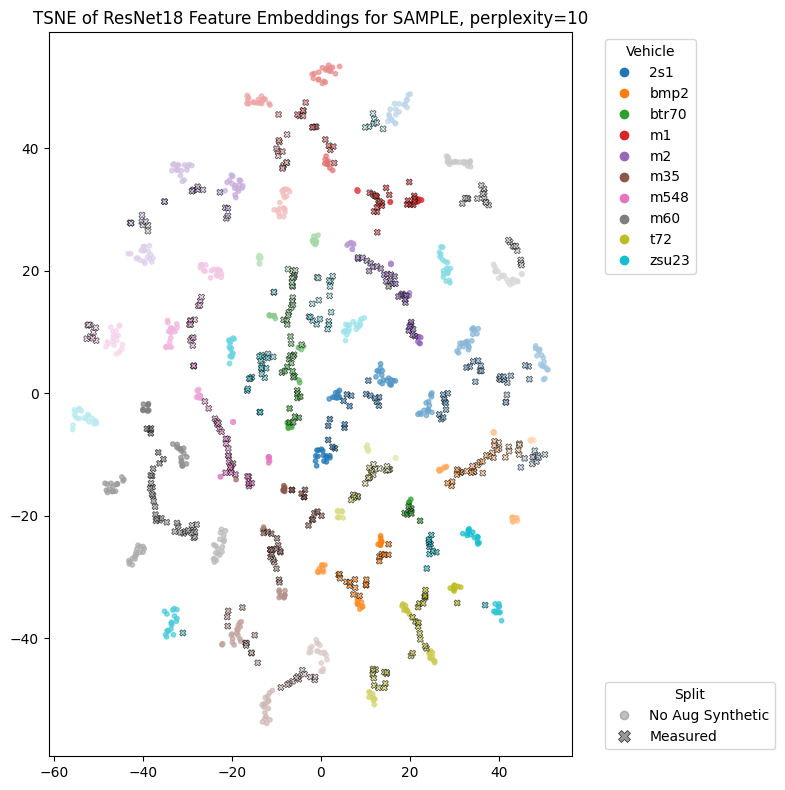

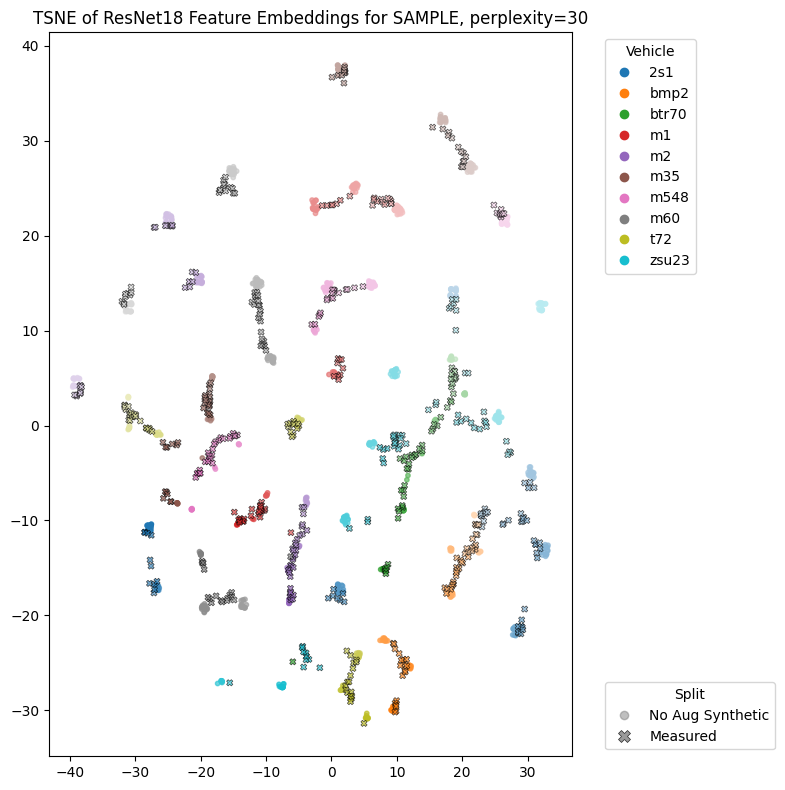

[2026-07-03 22:13:17.029] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


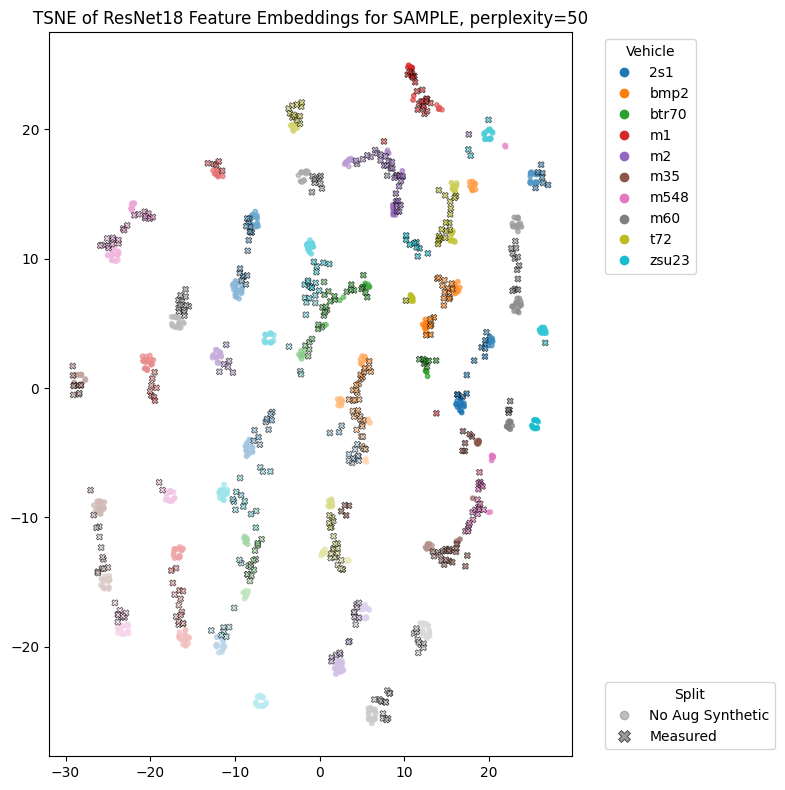

[2026-07-03 22:13:17.493] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-07-03 22:13:17.493] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


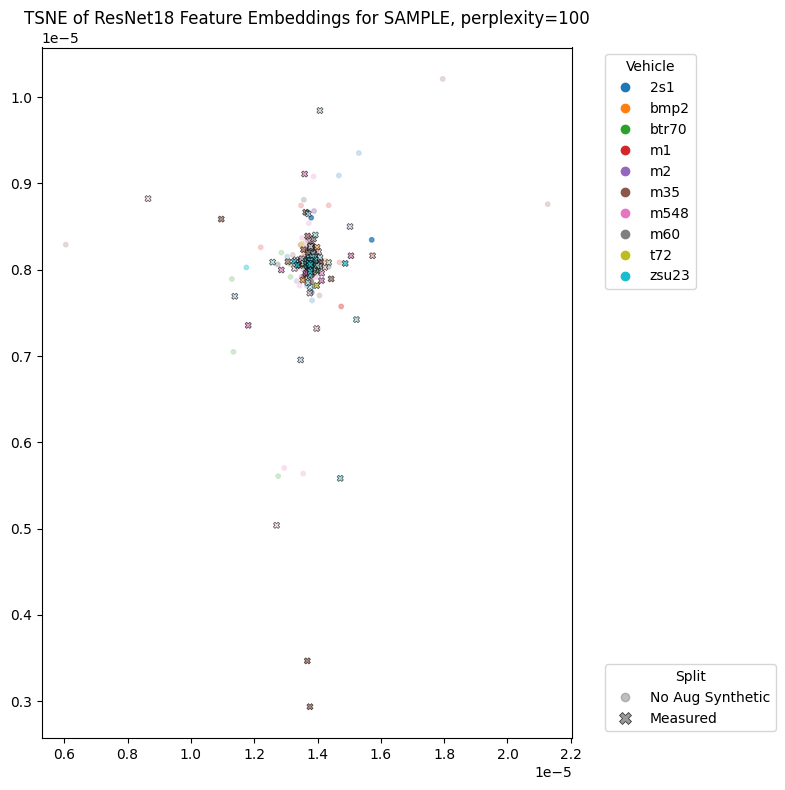

In [15]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

k = 1000
seed = 666
set_seed(seed)

device = torch.device("cuda:0")
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(test_plot_ds.classes))
)

dropout_rate = 0.1
for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
    for block in layer:
        block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
        def make_forward(b, orig_fwd):
            def forward(x):
                out = orig_fwd(x)
                return b.block_dropout(out)
            return forward
        block.forward = make_forward(block, block.forward)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()
for m in new_model.modules():
    if isinstance(m, nn.Dropout2d):
        m.train()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device=device)
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(combined_loader, desc="Evaluating", leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)

        bs = inputs.size(0)
        features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        labels_tensor[idx:idx+bs] = labels
        idx += bs


hook.remove()
torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 30, 50, 100]:
    
    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
        )

    features_2d = tsne.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_plot_ds), 0],
        features_2d[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d[len(train_plot_ds):, 0],
        features_2d[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"TSNE of ResNet18 Feature Embeddings for SAMPLE, perplexity={num}")
    plt.tight_layout()
    plt.show()

[2026-07-03 22:16:08.831] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


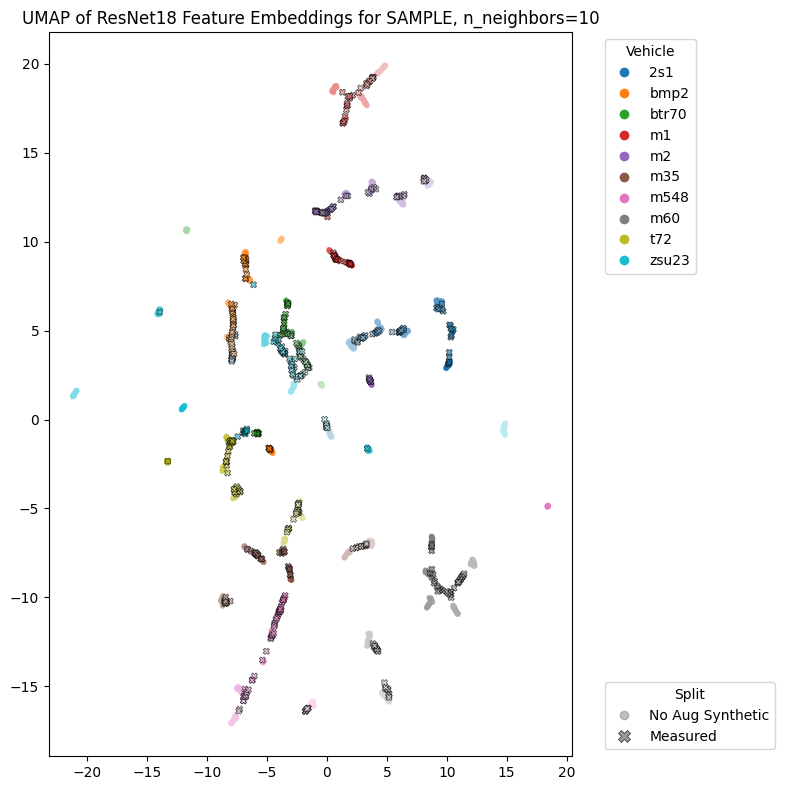

[2026-07-03 22:16:09.327] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


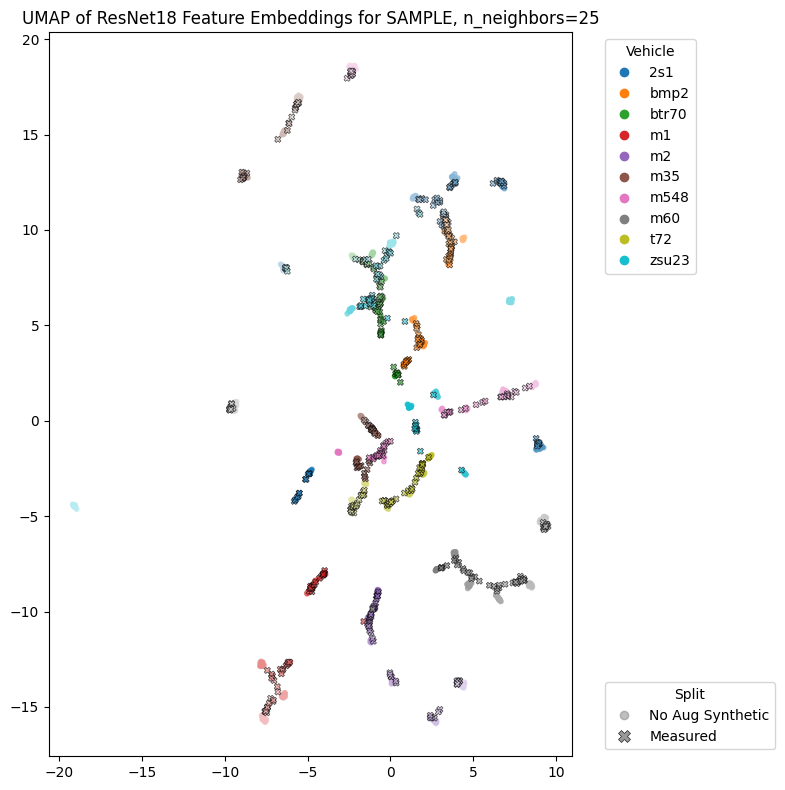

[2026-07-03 22:16:09.555] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


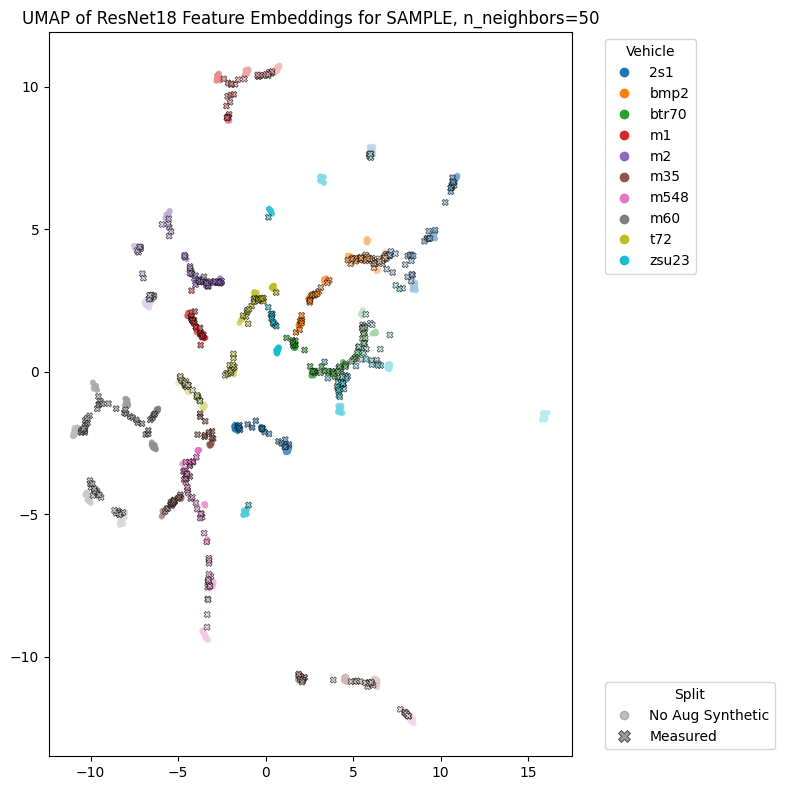

[2026-07-03 22:16:09.710] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


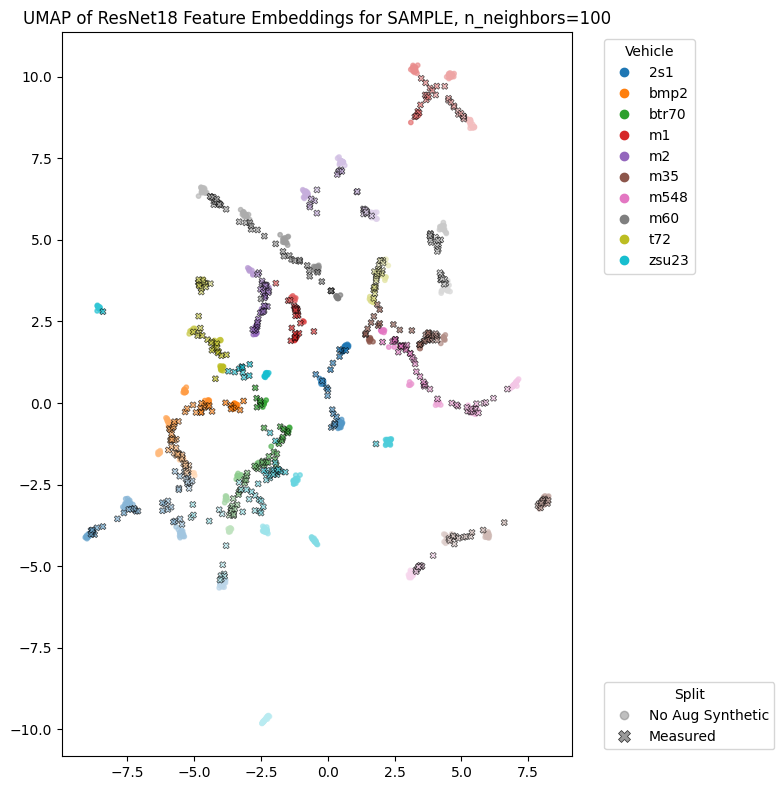

In [16]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

k = 1000
seed = 666
set_seed(seed)

device = torch.device("cuda:0")
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(test_plot_ds.classes))
)

dropout_rate = 0.1
for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
    for block in layer:
        block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
        def make_forward(b, orig_fwd):
            def forward(x):
                out = orig_fwd(x)
                return b.block_dropout(out)
            return forward
        block.forward = make_forward(block, block.forward)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()
for m in new_model.modules():
    if isinstance(m, nn.Dropout2d):
        m.train()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device=device)
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(combined_loader, desc="Evaluating", leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)

        bs = inputs.size(0)
        features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        labels_tensor[idx:idx+bs] = labels
        idx += bs


hook.remove()
torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 25, 50, 100]:

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [18]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
new_meas_ds_17 =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
new_no_aug_synth_ds_14_15_16 =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

k = 100
seed = 666
set_seed(seed)

device = torch.device("cuda:0")
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(new_meas_ds_17.classes))
)

dropout_rate = 0.1
for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
    for block in layer:
        block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
        def make_forward(b, orig_fwd):
            def forward(x):
                out = orig_fwd(x)
                return b.block_dropout(out)
            return forward
        block.forward = make_forward(block, block.forward)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()
for m in new_model.modules():
    if isinstance(m, nn.Dropout2d):
        m.train()

SSR_synth_loader = DataLoader(
    new_SSR_synth_ds_big_14_15_16, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(new_SSR_synth_ds_big_14_15_16)
SSR_synth_feats_gpu = torch.zeros((75* n_synth, 512), device = device)
SSR_synth_labels_gpu = torch.zeros(75 * n_synth, dtype = torch.long, device = device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
for epoch in tqdm(range(75), leave = False):
    with torch.no_grad():
        for inputs, labels in SSR_synth_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            feats_buffer.clear()
    
            # k forward passes, average probabilities, then classify
            preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
    
            bs = inputs.size(0)
            SSR_synth_feats_gpu[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
            SSR_synth_labels_gpu[idx:idx+bs] = labels
            idx += bs

hook.remove()
torch.cuda.synchronize()

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

synth_loader = DataLoader(
    new_no_aug_synth_ds_14_15_16, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(new_no_aug_synth_ds_14_15_16)
synth_feats_gpu  = torch.zeros(n_no_aug_synth, 512, device = device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype = torch.long, device = device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(synth_loader, leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)

        bs = inputs.size(0)
        synth_feats_gpu[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        synth_labels_gpu[idx:idx+bs] = labels
        idx += bs

hook.remove()
torch.cuda.synchronize()

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

meas_loader = DataLoader(
    new_meas_ds_17, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(new_meas_ds_17)
meas_feats_gpu  = torch.zeros(n_meas, 512, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(meas_loader, leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)

        bs = inputs.size(0)
        meas_feats_gpu[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        meas_labels_gpu[idx:idx+bs] = labels
        idx += bs

hook.remove()
torch.cuda.synchronize()

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

del SSR_synth_feats_gpu, SSR_synth_labels_gpu
del synth_feats_gpu, synth_labels_gpu  
del meas_feats_gpu, meas_labels_gpu
torch.cuda.empty_cache()

np.savez_compressed(
    os.path.join(workspace, "weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/seed666_ssr80_mc_feats_labels.npz"),
    SSR_synth_feats=SSR_synth_feats,
    SSR_synth_labels=SSR_synth_labels,
    synth_feats=synth_feats,
    synth_labels=synth_labels,
    meas_feats=meas_feats,
    meas_labels=meas_labels
)

In [21]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

for val in [10, 25, 30, 50, 100]:
    pca = PCA(n_components = val)
    combined_feats_pca = pca.fit_transform(combined_feats)
    print(f"Variance explained using {val} components: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained using 10 components: 0.540
Variance explained using 25 components: 0.899
Variance explained using 30 components: 0.928
Variance explained using 50 components: 0.966
Variance explained using 100 components: 0.985


Variance explained using 50 components: 0.966
[2026-07-03 23:19:30.941] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')


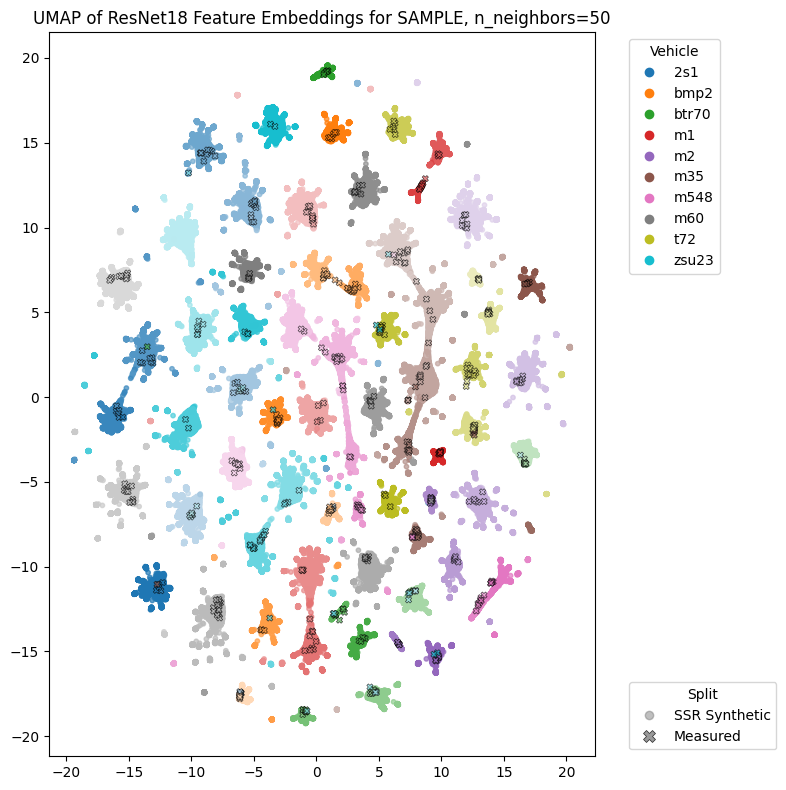

[2026-07-03 23:19:39.261] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:19:39.262] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


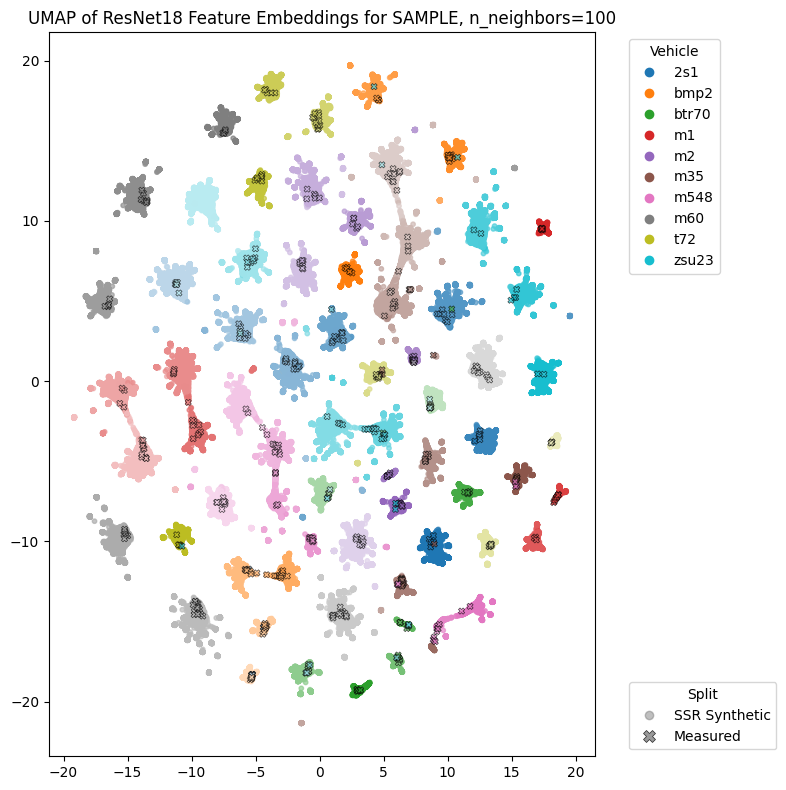

[2026-07-03 23:19:50.389] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:19:50.390] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:19:50.390] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


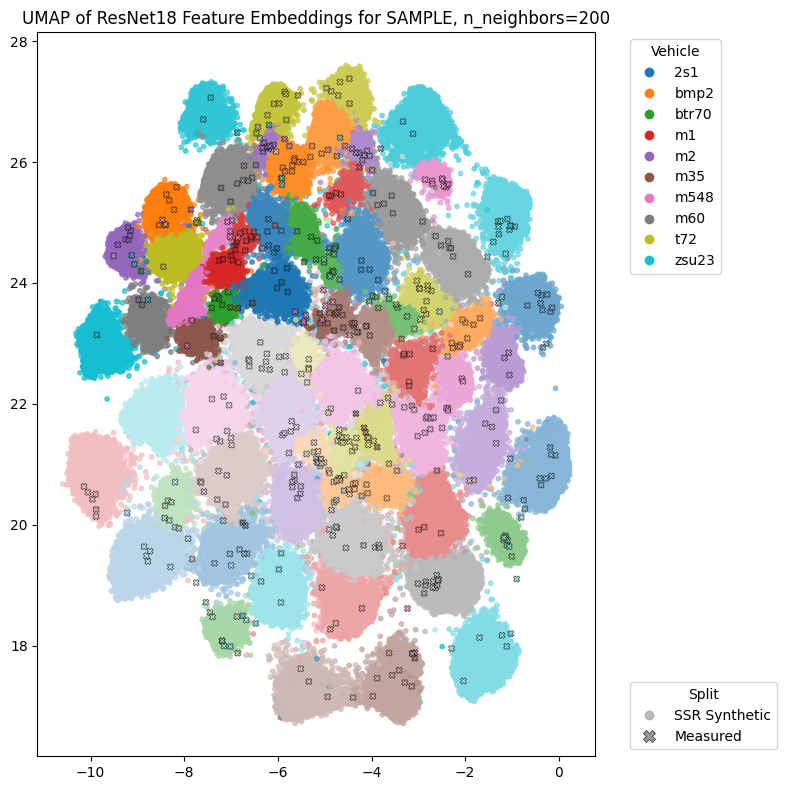

[2026-07-03 23:20:06.050] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:20:06.051] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:20:06.051] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


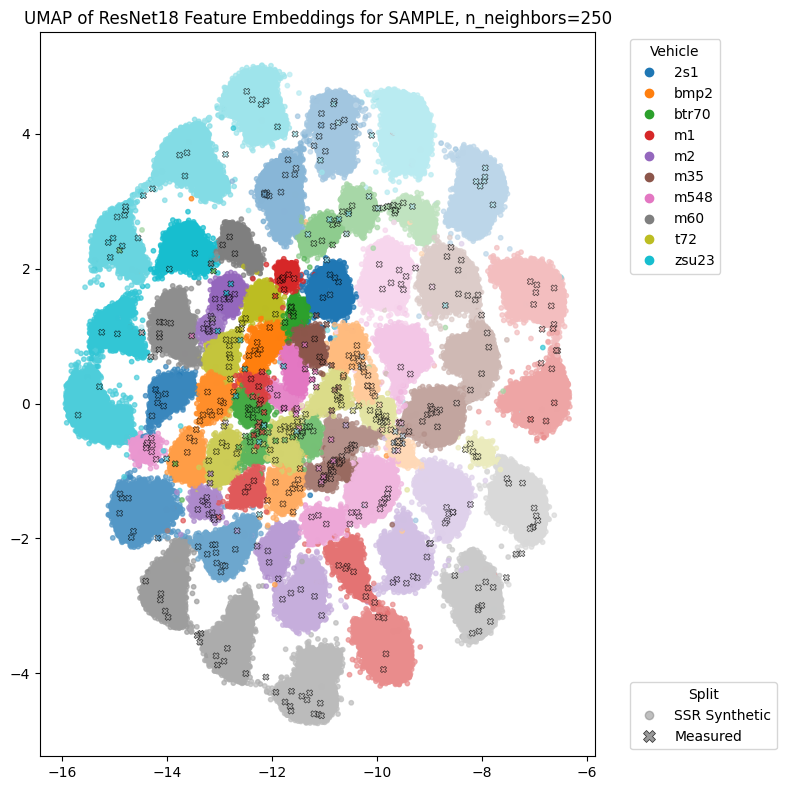

[2026-07-03 23:20:27.351] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:20:27.352] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:20:27.352] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


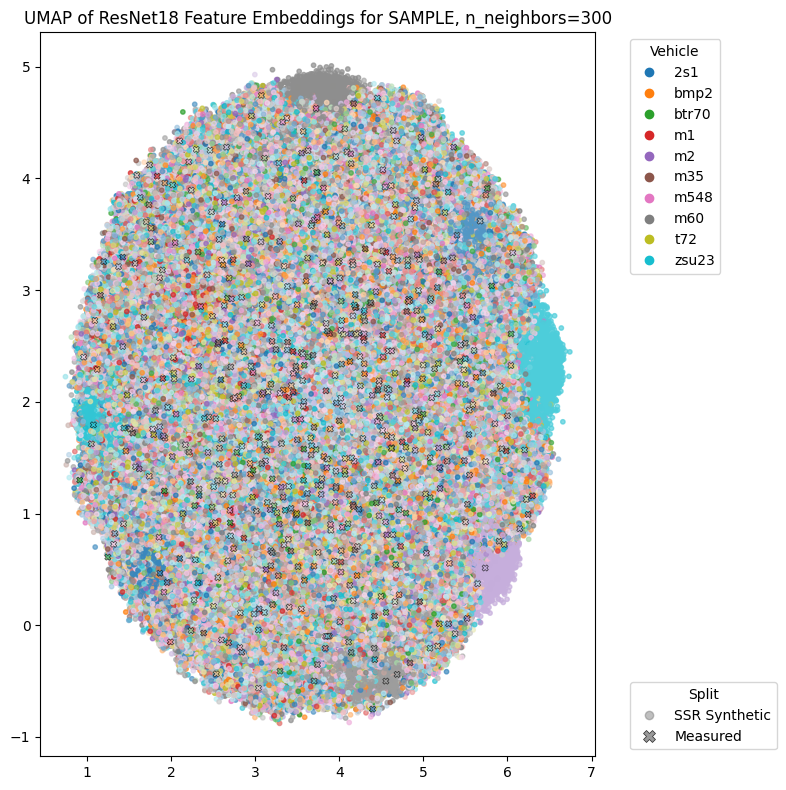

In [22]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

pca = PCA(n_components = 50)
combined_feats_pca = pca.fit_transform(combined_feats)
print(f"Variance explained using {50} components: {pca.explained_variance_ratio_.sum():.3f}")

for num in [50, 100, 200, 250, 300]:

    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine"
        )

    features_2d_umap = reducer.fit_transform(combined_feats)

    n_vehicles = len(new_SSR_synth_ds_14_15_16.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [23]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels,  synth_labels, meas_labels], axis=0)

for val in [10, 25, 30, 50, 100]:
    pca = PCA(n_components = val)
    combined_feats_pca = pca.fit_transform(combined_feats)
    print(f"Variance explained using {val} components: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained using 10 components: 0.540
Variance explained using 25 components: 0.899
Variance explained using 30 components: 0.928
Variance explained using 50 components: 0.966
Variance explained using 100 components: 0.985


Variance explained using 50 components: 0.966
[2026-07-03 23:21:49.502] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')


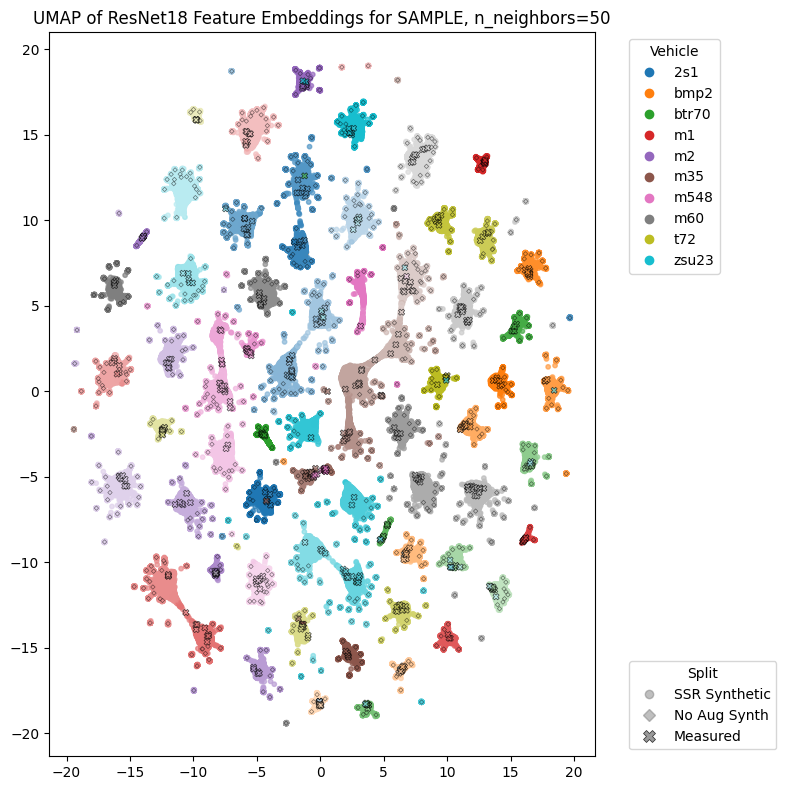

[2026-07-03 23:21:57.874] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:21:57.875] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


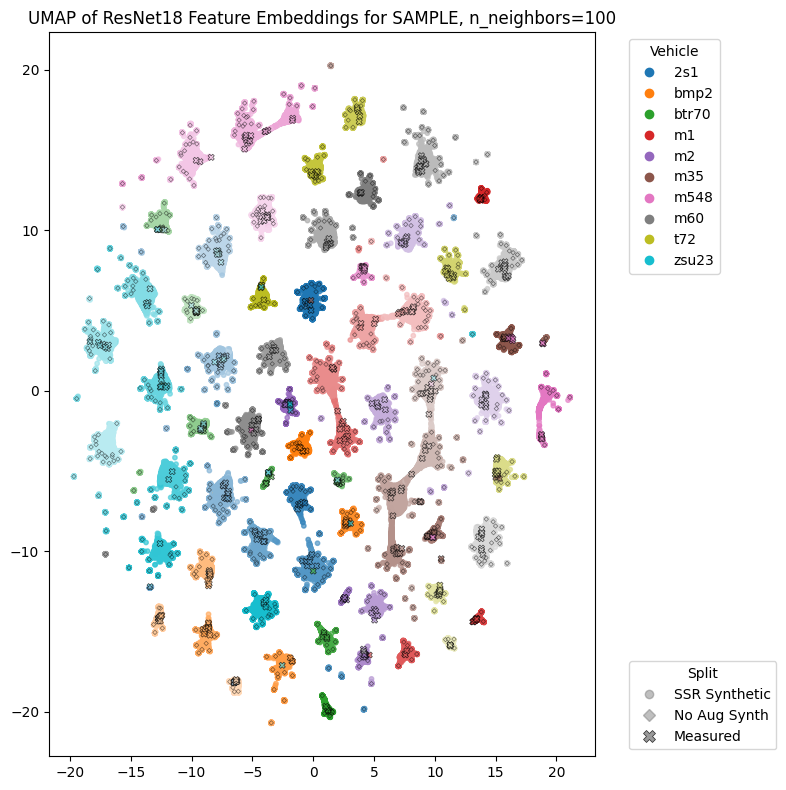

[2026-07-03 23:22:09.204] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:22:09.205] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:22:09.205] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


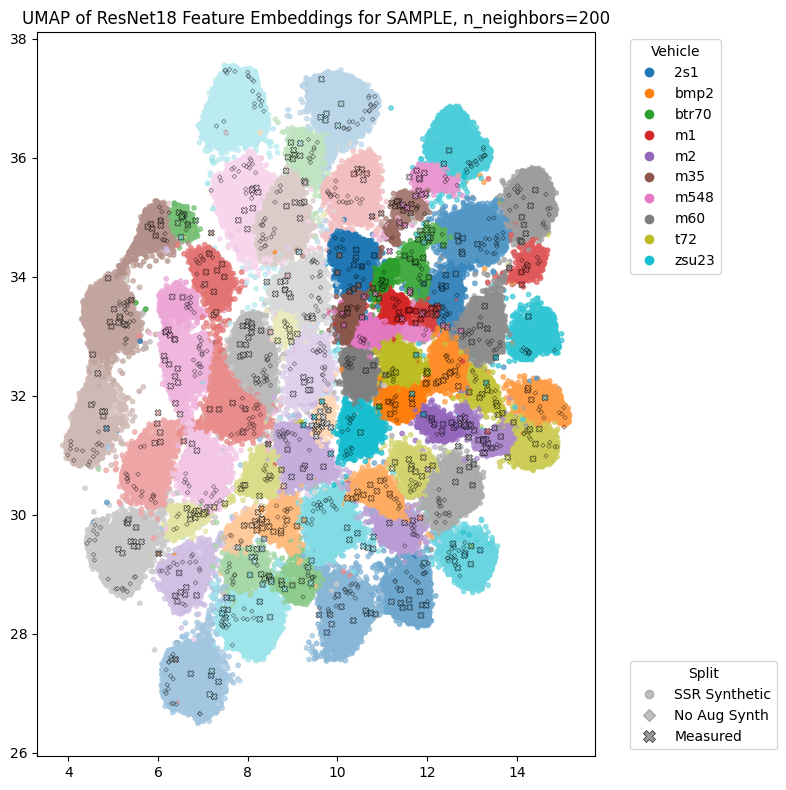

[2026-07-03 23:22:25.176] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:22:25.178] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:22:25.178] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


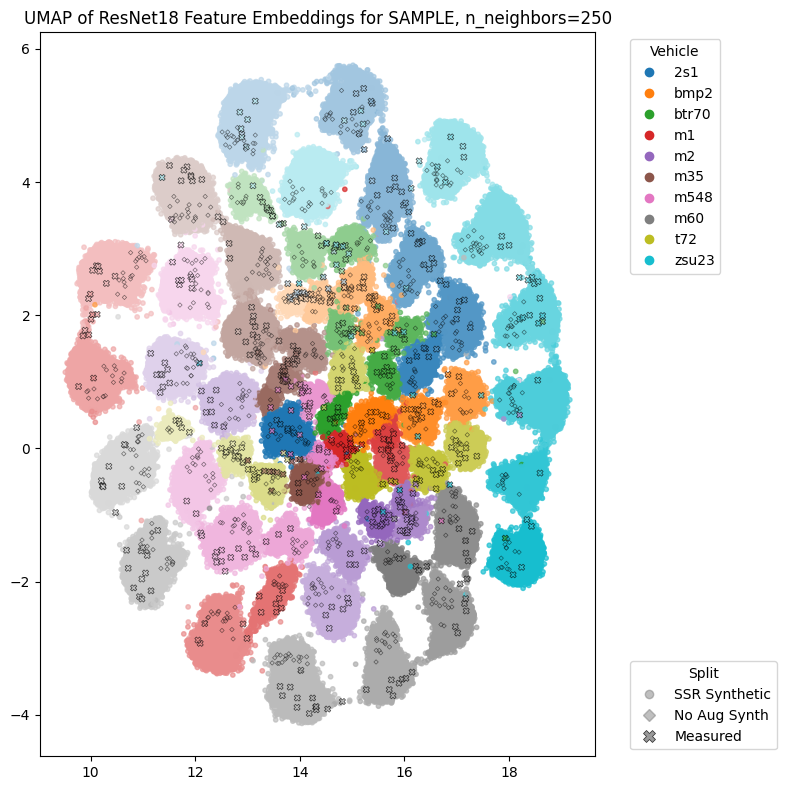

[2026-07-03 23:22:47.503] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 23:22:47.504] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 23:22:47.504] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


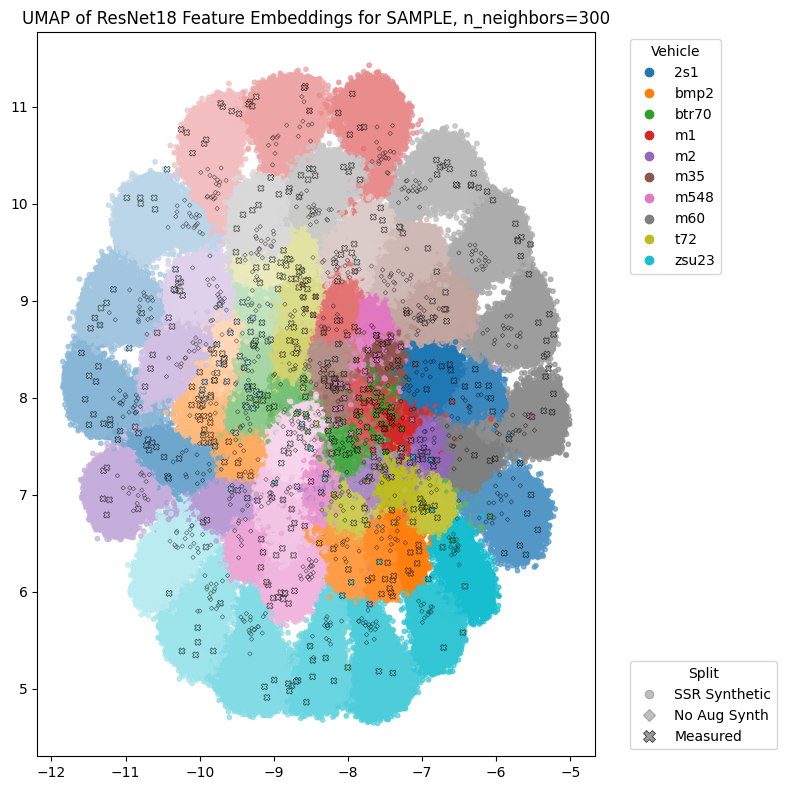

In [24]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels,  synth_labels, meas_labels], axis=0)

pca = PCA(n_components = 50)
combined_feats_pca = pca.fit_transform(combined_feats)
print(f"Variance explained using {50} components: {pca.explained_variance_ratio_.sum():.3f}")

for num in [50, 100, 200, 250, 300]:

    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine"
        )

    features_2d_umap = reducer.fit_transform(combined_feats)

    n_vehicles = len(new_SSR_synth_ds_14_15_16.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    synth_colors = labels_to_colors(combined_labels[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats) + len(synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 0],
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 1],
        c=synth_colors,
        s=5,
        alpha=0.5,
        linewidths=0.5,
        edgecolors="k",
        marker = "D"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [25]:
def _get_features_and_preds_from_mc_model(model, dataset, device, seed, k=1000):
    model = model.to(device)
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout2d):
            m.train()

    n_samples = len(dataset)
    features_tensor = torch.zeros((n_samples, 512), device=device)
    labels_tensor   = torch.zeros(n_samples, dtype=torch.long, device=device)
    preds_tensor    = torch.zeros(n_samples, dtype=torch.long, device=device)

    hook = model.avgpool.register_forward_hook(
        lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
    )

    idx = 0
    feats_buffer = []
    with torch.no_grad():
        for inputs, targets in tqdm(
            DataLoader(dataset, batch_size=32, shuffle=False, num_workers=8,
                    pin_memory=True, persistent_workers=True, prefetch_factor = 4,
                    worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
                    ),
                    leave=False):

            inputs  = inputs.to(device)
            targets = targets.to(device)
            feats_buffer.clear()

            preds_mc = torch.stack([model(inputs) for _ in range(k)], dim=0)

            bs = inputs.size(0)
            features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
            labels_tensor[idx:idx+bs] = targets
            preds_tensor[idx:idx+bs] = torch.softmax(preds_mc, dim=-1).mean(0).argmax(1)
            idx += bs

    hook.remove()
    torch.cuda.synchronize()

    _features = features_tensor.cpu().numpy()
    _labels = labels_tensor.cpu().numpy()
    _preds = preds_tensor.cpu().numpy()

    return cp.asarray(_features), cp.asarray(_labels), cp.asarray(_preds)

In [26]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
new_meas_ds_17 =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
new_no_aug_synth_ds_14_15_16 =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

seed_lst = [666]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    set_seed(seed)
    
    # Reconstruct architecture exactly as trained
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, len(new_meas_ds_17.classes))
    )
    
    dropout_rate = 0.1
    for layer in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in layer:
            block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
            def make_forward(b, orig_fwd):
                def forward(x):
                    out = orig_fwd(x)
                    return b.block_dropout(out)
                return forward
            block.forward = make_forward(block, block.forward)

    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"),
        map_location=device
    ))

    synth_features, synth_labels, _ = _get_features_and_preds_from_mc_model(model, new_no_aug_synth_ds_14_15_16, device, seed, k = 1000)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_mc_model(model, new_meas_ds_17, device, seed, k = 1000)

    old_synth_labels = cp.array([new_to_old_classes[synth_labels[i].item()] for i in range(len(synth_labels))])
    old_meas_labels = cp.array([new_to_old_classes[meas_labels[i].item()] for i in range(len(meas_labels))])
    old_meas_preds = cp.array([new_to_old_classes[meas_preds[i].item()] for i in range(len(meas_preds))])

Evaluating Run 0: seed 666


In [27]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, old_meas_labels, synth_features, old_synth_labels, metric = "cosine"
)

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.500  0.804  0.913  (n=46)
bmp2        0.635  0.865  0.962  (n=52)
btr70       0.600  0.911  0.978  (n=45)
m1          0.540  0.760  0.900  (n=50)
m2          0.623  0.925  1.000  (n=53)
m35         0.617  0.830  0.894  (n=47)
m548        0.644  0.889  0.956  (n=45)
m60         0.508  0.712  0.881  (n=59)
t72         0.692  0.846  0.923  (n=52)
zsu23       0.438  0.719  0.906  (n=32)
----------------------------
Overall     0.584  0.827  0.931  (n=481)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         23.000  37.000  42.000  (n=46)
bmp2        33.000  45.000  50.000  (n=52)
btr70       27.000  41.000  44.000  (n=45)
m1          27.000  38.000  45.000  (n=50)
m2          33.000  49.000  53.000  (n=53)
m35         29.000  39.000  42.000  (n=47)
m548        29.000  40.000  43.000  (n=45)
m60         30.000  42.000  52.000  (n=59)
t72         36.000  44.000  48.000  (n=52)
zsu23       14.000  23.000 

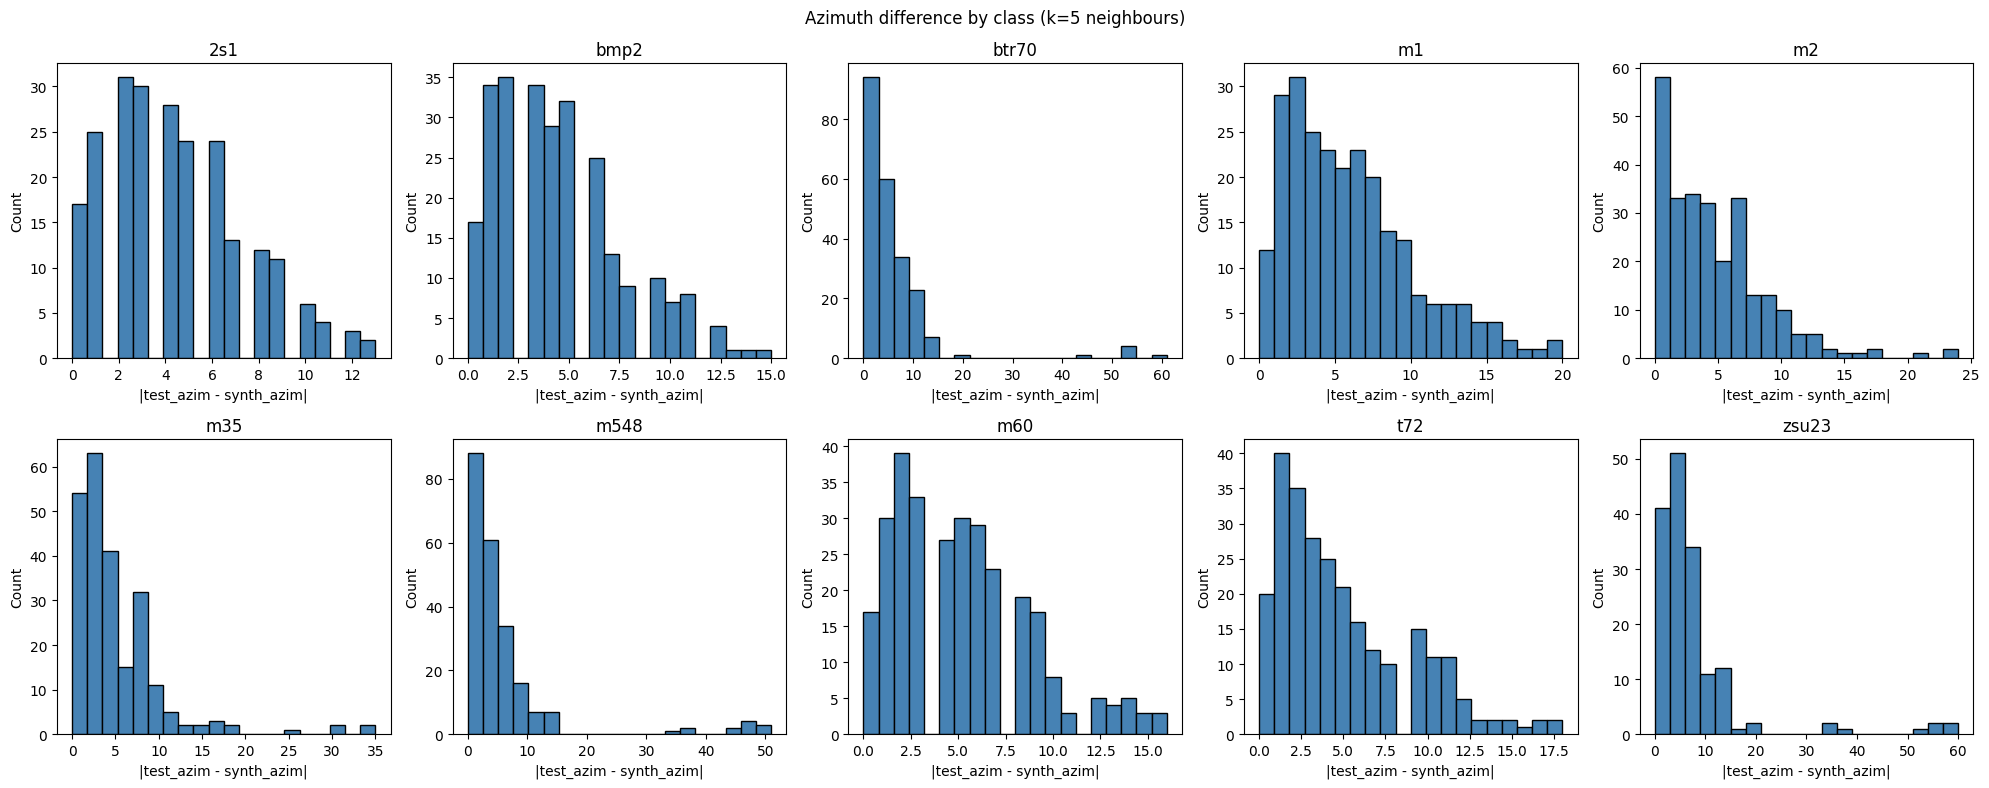

In [29]:
results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(old_meas_preds) == cp.asnumpy(old_meas_labels)
correct_classes = cp.asnumpy(old_meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(test_ds.dataset, azim_diffs, correct_classes)